# ML Methods for Daily Listening Change

**Research Question:** *How does my Spotify listening behavior change across days, both in terms of listening intensity and in terms of the kind of music I listen to?*

This notebook is designed to match the main question of the project more directly than a pure context-classification notebook. The focus here is not mainly whether a model can recognize exam or vacation days, but whether daily listening variation can be modeled and interpreted using:

- listening duration and frequency
- artist and track diversity
- engagement behavior such as skip and shuffle
- daily audio-feature summaries that act as a proxy for music character
- special-day and break-period context labels

**Workflow Overview**

- Load the datasets
- Build a daily listening dataset
- Engineer behavioral, temporal, audio, and context features
- Use a chronological train-test split
- Define a preprocessing pipeline
- Compare several regression models for daily listening time
- Interpret model comparison results
- Cross-validate and tune the main Random Forest regressor
- Evaluate predictions with error analysis and feature importance
- Add an optional classification task for daily listening intensity tiers

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 170)

BASE_DIR = Path.home() / "Desktop" / "DSA210 TERM PROJECT"

STREAMING_PATH = BASE_DIR / "extended_streaming_history_data" / "spotify_cleaned.csv"
SPECIAL_DATES_PATH = BASE_DIR / "special_days_data" / "special_dates.csv"
TRAVEL_BREAKS_PATH = BASE_DIR / "special_days_data" / "travel_and_break_periods.csv"
DAILY_AUDIO_PATH = BASE_DIR / "extended_streaming_history_data" / "spotify_daily_audio_features.csv"
AUDIO_SUMMARY_PATH = BASE_DIR / "extended_streaming_history_data" / "audio_feature_enrichment_summary.csv"


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## - Data Sources and Initial Loading

This notebook uses the same core project data, but it treats it from a daily-behavior perspective.

The main input sources are:

- `spotify_cleaned.csv`: cleaned event-level streaming history
- `special_dates.csv`: calendar-based labels such as exams, deadlines, and stress periods
- `travel_and_break_periods.csv`: travel, break, and holiday intervals
- `spotify_daily_audio_features.csv`: daily audio-feature summaries derived from external enrichment
- `audio_feature_enrichment_summary.csv`: coverage diagnostics for the audio-feature merge

Because the main research question is day-oriented, all modeling in this notebook is built at the **daily level**.

spotify_cleaned shape: (175826, 12)
special_dates shape: (251, 8)
travel_breaks shape: (45, 11)
daily_audio shape: (2384, 14)
audio_summary shape: (9, 2)


,ts,date,hour,weekday,ms_played,master_metadata_track_name,master_metadata_album_artist_name,reason_start,reason_end,shuffle,skipped,session_id
0,2018-09-21 16:18:51+00:00,2018-09-21,16,Friday,197560,Mary Jane (Ilkay Şencan Remix),Burry Soprano,clickrow,trackdone,False,False,0
1,2018-09-21 16:21:06+00:00,2018-09-21,16,Friday,9980,Uyan,Velet,trackdone,endplay,False,False,0
2,2018-09-21 16:58:43+00:00,2018-09-21,16,Friday,83360,"RAF (feat. A$AP Rocky, Playboi Carti, Quavo, L...",A$AP Mob,clickrow,logout,False,False,1
3,2018-09-21 17:01:45+00:00,2018-09-21,17,Friday,166470,"RAF (feat. A$AP Rocky, Playboi Carti, Quavo, L...",A$AP Mob,appload,endplay,False,False,1
4,2018-09-21 17:05:14+00:00,2018-09-21,17,Friday,209680,Gorgeous,Taylor Swift,clickrow,trackdone,False,False,1


,date,is_exam,is_deadline,is_academic_event,is_personal,is_stress_period,source_events,categories
0,2024-07-15,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
1,2024-07-16,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
2,2024-07-17,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
3,2024-07-18,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam
4,2024-07-19,0,0,0,0,1,Ehliyet E-sınav,stress_before_exam


,start_date,end_date,period_type,period_name,location,is_travel_vacation,is_school_break,is_public_holiday_block,is_long_break,source,notes
0,2018-06-14,2018-06-17,public_holiday_block,ramadan_feast_2018,Turkey,0,0,1,1,official_holiday_calendar,Ramazan Bayrami incl. eve
1,2018-08-20,2018-08-24,public_holiday_block,eid_al_adha_2018,Turkey,0,0,1,1,official_holiday_calendar,Kurban Bayrami incl. eve
2,2018-08-27,2018-09-09,travel_vacation,kktc_trip_2018,KKTC,1,0,0,1,user_provided,NaN
3,2019-01-21,2019-02-01,school_break,semester_break_2019,Turkey,0,1,0,1,official_calendar,Yariyil tatili
4,2019-06-03,2019-06-06,public_holiday_block,ramadan_feast_2019,Turkey,0,0,1,1,official_holiday_calendar,Ramazan Bayrami incl. eve


,date,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,liveness,loudness,key,mode,audio_feature_event_count,audio_feature_total_ms
0,2018-09-21,0.675533,0.671463,0.408398,124.818250,0.158255,0.005862,0.099295,0.189015,-5.866255,0.0,0.0,31,6467782
1,2018-09-22,0.662511,0.664218,0.429243,128.335123,0.177896,0.007729,0.085724,0.165909,-6.033540,0.0,0.0,23,4901792
2,2018-09-23,0.658993,0.671208,0.434016,121.147643,0.203549,0.006793,0.078802,0.178489,-5.838344,5.0,0.0,54,11544416
3,2018-09-24,0.644386,0.700586,0.523318,113.026192,0.120633,0.000234,0.110507,0.209508,-5.135249,10.0,0.0,14,2893779
4,2018-09-25,0.678575,0.722845,0.474374,112.507114,0.175027,0.018735,0.098913,0.184330,-5.092380,10.0,1.0,14,2076630


,metric,value
0,source_dataset,Faizasb/spotify-tracks-dataset + RecSysTUM/Mil...
1,unique_tracks_total,28660.0
2,unique_tracks_with_audio_features,4316.0
3,unique_track_match_rate,0.150593
4,stream_weighted_track_match_rate,0.17092
5,event_rows_total,185469.0
6,event_rows_with_audio_features,31595.0
7,event_match_rate,0.170352
8,ms_weighted_event_match_rate,0.188911


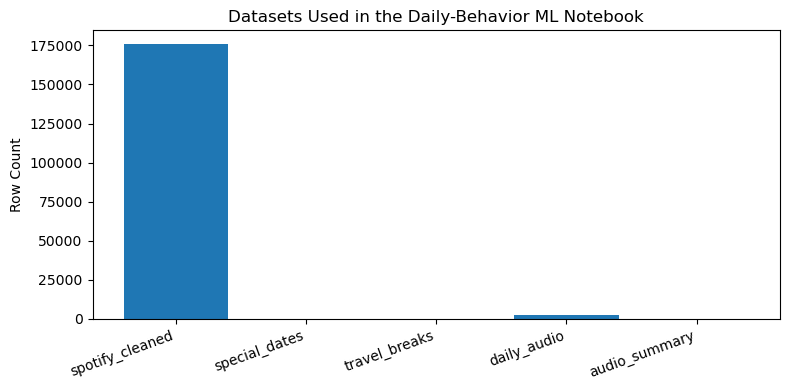

In [2]:
spotify_df = pd.read_csv(STREAMING_PATH)
special_dates_df = pd.read_csv(SPECIAL_DATES_PATH)
travel_breaks_df = pd.read_csv(TRAVEL_BREAKS_PATH)
daily_audio_df = pd.read_csv(DAILY_AUDIO_PATH)
audio_summary_df = pd.read_csv(AUDIO_SUMMARY_PATH)

dataset_size_df = pd.DataFrame(
    {
        "dataset": [
            "spotify_cleaned",
            "special_dates",
            "travel_breaks",
            "daily_audio",
            "audio_summary",
        ],
        "rows": [
            len(spotify_df),
            len(special_dates_df),
            len(travel_breaks_df),
            len(daily_audio_df),
            len(audio_summary_df),
        ],
    }
)

print("spotify_cleaned shape:", spotify_df.shape)
print("special_dates shape:", special_dates_df.shape)
print("travel_breaks shape:", travel_breaks_df.shape)
print("daily_audio shape:", daily_audio_df.shape)
print("audio_summary shape:", audio_summary_df.shape)

display(spotify_df.head())
display(special_dates_df.head())
display(travel_breaks_df.head())
display(daily_audio_df.head())
display(audio_summary_df)

plt.figure(figsize=(8, 4))
plt.bar(dataset_size_df["dataset"], dataset_size_df["rows"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Row Count")
plt.title("Datasets Used in the Daily-Behavior ML Notebook")
plt.tight_layout()
plt.show()

## - Building the Daily Listening Table

The Spotify export is event-based, so it must be transformed into one row per day before modeling.  
This step creates a daily listening table containing:

- listening duration
- stream frequency
- diversity indicators
- engagement signals
- time-of-day structure
- contextual labels

This daily table is the core analytical object for the entire notebook.

,dataset,start,end,rows
0,daily_spotify_table,2018-09-21,2026-03-30,2686
1,special_dates_window,2024-07-15,2026-05-17,672
2,travel_break_window,2018-06-14,2025-07-14,2588


,date,total_ms,num_streams,unique_artists,unique_tracks,skip_rate,shuffle_rate,session_count,avg_stream_length_ms,median_stream_length_ms,avg_hour,std_hour,weekday_num,month,year,weekend_flag,dominant_reason_start,dominant_reason_end,total_minutes,avg_stream_length,median_stream_length,night_share,morning_share,afternoon_share,evening_share,reason_end_trackdone,reason_end_endplay,reason_start_clickrow,reason_start_trackdone,is_exam,is_deadline,is_academic_event,is_personal,is_stress_period,source_events,categories,within_special_window,is_travel_vacation,is_school_break,is_public_holiday_block,is_long_break,within_travel_window,is_lgs_prep,is_yks_prep,is_any_entrance_exam_prep,is_lgs_high_stress,is_yks_high_stress,is_entrance_exam_high_stress,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,liveness,loudness,key,mode,audio_feature_event_count,audio_feature_total_ms
0,2018-09-21,10998656,54,52,53,0.0,0.000,2,203678.814815,208392.0,18.018519,1.054921,4.0,9.0,2018.0,0,trackdone,trackdone,183.310933,3.394647,3.473200,0.0,0.000000,0.351852,0.648148,0.944444,0.037037,0.055556,0.925926,0,0,0,0,0,,,0,0,0,0,0,1,0,0,0,0,0,0,0.675533,0.671463,0.408398,124.818250,0.158255,0.005862,0.099295,0.189015,-5.866255,0.0,0.0,31.0,6467782.0
1,2018-09-22,9692768,46,43,44,0.0,0.000,1,210712.347826,213220.5,17.804348,0.833188,5.0,9.0,2018.0,1,trackdone,trackdone,161.546133,3.511872,3.553675,0.0,0.000000,0.413043,0.586957,0.978261,0.000000,0.000000,0.956522,0,0,0,0,0,,,0,0,0,0,0,1,0,0,0,0,0,0,0.662511,0.664218,0.429243,128.335123,0.177896,0.007729,0.085724,0.165909,-6.033540,0.0,0.0,23.0,4901792.0
2,2018-09-23,22268149,105,73,81,0.0,0.000,1,212077.609524,213132.0,10.980952,1.911408,6.0,9.0,2018.0,1,trackdone,trackdone,371.135817,3.534627,3.552200,0.0,0.580952,0.419048,0.000000,0.980952,0.000000,0.000000,0.990476,0,0,0,0,0,,,0,0,0,0,0,1,0,0,0,0,0,0,0.658993,0.671208,0.434016,121.147643,0.203549,0.006793,0.078802,0.178489,-5.838344,5.0,0.0,54.0,11544416.0
3,2018-09-24,5524854,27,20,22,0.0,1.000,2,204624.222222,203400.0,14.814815,1.272098,0.0,9.0,2018.0,0,trackdone,trackdone,92.080900,3.410404,3.390000,0.0,0.000000,1.000000,0.000000,0.962963,0.000000,0.000000,0.925926,0,0,0,0,0,,,0,0,0,0,0,1,0,0,0,0,0,0,0.644386,0.700586,0.523318,113.026192,0.120633,0.000234,0.110507,0.209508,-5.135249,10.0,0.0,14.0,2893779.0
4,2018-09-25,4691250,40,30,32,0.0,0.725,3,117281.250000,143828.0,11.550000,4.443087,1.0,9.0,2018.0,0,trackdone,trackdone,78.187500,1.954687,2.397133,0.3,0.000000,0.700000,0.000000,0.525000,0.200000,0.150000,0.550000,0,0,0,0,0,,,0,0,0,0,0,1,0,0,0,0,0,0,0.678575,0.722845,0.474374,112.507114,0.175027,0.018735,0.098913,0.184330,-5.092380,10.0,1.0,14.0,2076630.0


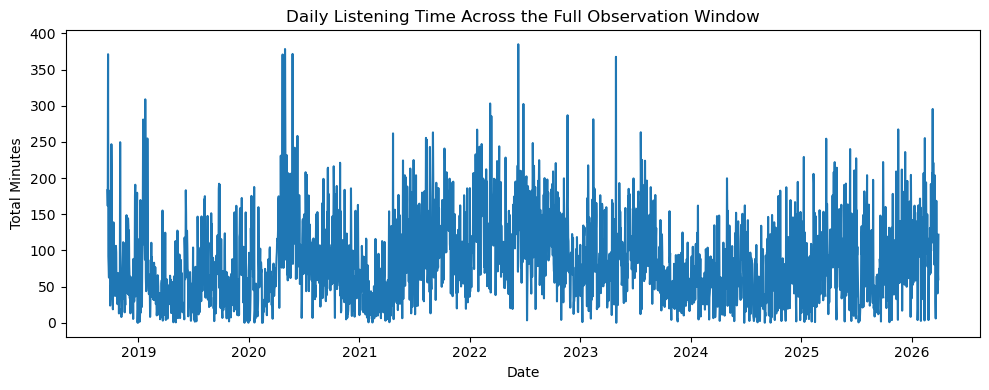

In [3]:
spotify_df["ts"] = pd.to_datetime(spotify_df["ts"], errors="coerce", utc=True)
spotify_df = spotify_df.dropna(subset=["ts"]).copy()
spotify_df["local_ts"] = spotify_df["ts"].dt.tz_convert(None)
spotify_df["date"] = spotify_df["local_ts"].dt.normalize()
spotify_df["hour"] = spotify_df["local_ts"].dt.hour
spotify_df["weekday_num"] = spotify_df["local_ts"].dt.weekday
spotify_df["month"] = spotify_df["local_ts"].dt.month
spotify_df["year"] = spotify_df["local_ts"].dt.year
spotify_df["is_weekend"] = spotify_df["weekday_num"].isin([5, 6]).astype(int)
spotify_df["shuffle"] = spotify_df["shuffle"].fillna(False).astype(int)
spotify_df["skipped"] = spotify_df["skipped"].fillna(False).astype(int)
spotify_df["master_metadata_track_name"] = spotify_df["master_metadata_track_name"].fillna("Unknown Track")
spotify_df["master_metadata_album_artist_name"] = spotify_df["master_metadata_album_artist_name"].fillna("Unknown Artist")

daypart_conditions = [
    spotify_df["hour"].between(0, 5),
    spotify_df["hour"].between(6, 11),
    spotify_df["hour"].between(12, 17),
    spotify_df["hour"].between(18, 23),
]
spotify_df["daypart"] = np.select(
    daypart_conditions,
    ["night", "morning", "afternoon", "evening"],
    default="unknown",
)


def safe_mode(series: pd.Series) -> str:
    values = series.dropna().astype(str)
    if values.empty:
        return ""
    return values.mode().iloc[0]


daily_df = (
    spotify_df.groupby("date", as_index=False)
    .agg(
        total_ms=("ms_played", "sum"),
        num_streams=("ms_played", "size"),
        unique_artists=("master_metadata_album_artist_name", "nunique"),
        unique_tracks=("master_metadata_track_name", "nunique"),
        skip_rate=("skipped", "mean"),
        shuffle_rate=("shuffle", "mean"),
        session_count=("session_id", "nunique"),
        avg_stream_length_ms=("ms_played", "mean"),
        median_stream_length_ms=("ms_played", "median"),
        avg_hour=("hour", "mean"),
        std_hour=("hour", "std"),
        weekday_num=("weekday_num", "median"),
        month=("month", "median"),
        year=("year", "median"),
        weekend_flag=("is_weekend", "max"),
        dominant_reason_start=("reason_start", safe_mode),
        dominant_reason_end=("reason_end", safe_mode),
    )
)
daily_df["total_minutes"] = daily_df["total_ms"] / 60000
daily_df["avg_stream_length"] = daily_df["avg_stream_length_ms"] / 60000
daily_df["median_stream_length"] = daily_df["median_stream_length_ms"] / 60000
daily_df["std_hour"] = daily_df["std_hour"].fillna(0)

daypart_df = (
    spotify_df.pivot_table(
        index="date",
        columns="daypart",
        values="ms_played",
        aggfunc="size",
        fill_value=0,
    )
    .rename_axis(columns=None)
    .reset_index()
)
for expected_daypart in ["night", "morning", "afternoon", "evening"]:
    if expected_daypart not in daypart_df.columns:
        daypart_df[expected_daypart] = 0
daypart_total = daypart_df[["night", "morning", "afternoon", "evening"]].sum(axis=1).replace(0, np.nan)
for column in ["night", "morning", "afternoon", "evening"]:
    daypart_df[f"{column}_share"] = (daypart_df[column] / daypart_total).fillna(0)
daypart_df = daypart_df[["date", "night_share", "morning_share", "afternoon_share", "evening_share"]]

reason_df = (
    spotify_df.assign(
        reason_end_trackdone=(spotify_df["reason_end"].fillna("") == "trackdone").astype(int),
        reason_end_endplay=(spotify_df["reason_end"].fillna("") == "endplay").astype(int),
        reason_start_clickrow=(spotify_df["reason_start"].fillna("") == "clickrow").astype(int),
        reason_start_trackdone=(spotify_df["reason_start"].fillna("") == "trackdone").astype(int),
    )
    .groupby("date", as_index=False)[
        [
            "reason_end_trackdone",
            "reason_end_endplay",
            "reason_start_clickrow",
            "reason_start_trackdone",
        ]
    ]
    .mean()
)

daily_df = daily_df.merge(daypart_df, on="date", how="left").merge(reason_df, on="date", how="left")

special_dates_df["date"] = pd.to_datetime(special_dates_df["date"], errors="coerce").dt.normalize()
special_binary_cols = [
    "is_exam",
    "is_deadline",
    "is_academic_event",
    "is_personal",
    "is_stress_period",
]
special_range = pd.date_range(special_dates_df["date"].min(), special_dates_df["date"].max(), freq="D")
special_daily_df = pd.DataFrame({"date": special_range}).merge(special_dates_df, on="date", how="left")
special_daily_df[special_binary_cols] = special_daily_df[special_binary_cols].fillna(0).astype(int)
for column in ["source_events", "categories"]:
    special_daily_df[column] = special_daily_df[column].fillna("")
special_daily_df["within_special_window"] = 1

travel_breaks_df["start_date"] = pd.to_datetime(travel_breaks_df["start_date"], errors="coerce").dt.normalize()
travel_breaks_df["end_date"] = pd.to_datetime(travel_breaks_df["end_date"], errors="coerce").dt.normalize()
travel_rows = []
for _, row in travel_breaks_df.dropna(subset=["start_date", "end_date"]).iterrows():
    for current_date in pd.date_range(row["start_date"], row["end_date"], freq="D"):
        travel_rows.append(
            {
                "date": current_date,
                "is_travel_vacation": int(row.get("is_travel_vacation", 0)),
                "is_school_break": int(row.get("is_school_break", 0)),
                "is_public_holiday_block": int(row.get("is_public_holiday_block", 0)),
                "is_long_break": int(row.get("is_long_break", 0)),
            }
        )
travel_daily_df = pd.DataFrame(travel_rows)
if not travel_daily_df.empty:
    travel_daily_df = travel_daily_df.groupby("date", as_index=False).max()
travel_full_range = pd.date_range(travel_breaks_df["start_date"].min(), travel_breaks_df["end_date"].max(), freq="D")
travel_daily_df = pd.DataFrame({"date": travel_full_range}).merge(travel_daily_df, on="date", how="left")
for column in ["is_travel_vacation", "is_school_break", "is_public_holiday_block", "is_long_break"]:
    travel_daily_df[column] = travel_daily_df[column].fillna(0).astype(int)
travel_daily_df["within_travel_window"] = 1

entrance_df = pd.DataFrame({"date": pd.to_datetime(daily_df["date"]).sort_values().unique()})
entrance_df["is_lgs_prep"] = entrance_df["date"].between("2019-09-01", "2020-06-30").astype(int)
entrance_df["is_yks_prep"] = entrance_df["date"].between("2023-09-01", "2024-06-30").astype(int)
entrance_df["is_any_entrance_exam_prep"] = entrance_df[["is_lgs_prep", "is_yks_prep"]].max(axis=1)
entrance_df["is_lgs_high_stress"] = entrance_df["date"].between("2020-03-01", "2020-06-30").astype(int)
entrance_df["is_yks_high_stress"] = entrance_df["date"].between("2024-03-01", "2024-06-30").astype(int)
entrance_df["is_entrance_exam_high_stress"] = entrance_df[["is_lgs_high_stress", "is_yks_high_stress"]].max(axis=1)

daily_audio_df["date"] = pd.to_datetime(daily_audio_df["date"], errors="coerce").dt.normalize()

ml_df = (
    daily_df.merge(special_daily_df, on="date", how="left")
    .merge(travel_daily_df, on="date", how="left")
    .merge(entrance_df, on="date", how="left")
    .merge(daily_audio_df, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

fill_zero_columns = special_binary_cols + [
    "within_special_window",
    "is_travel_vacation",
    "is_school_break",
    "is_public_holiday_block",
    "is_long_break",
    "within_travel_window",
    "is_lgs_prep",
    "is_yks_prep",
    "is_any_entrance_exam_prep",
    "is_lgs_high_stress",
    "is_yks_high_stress",
    "is_entrance_exam_high_stress",
]
for column in fill_zero_columns:
    ml_df[column] = ml_df[column].fillna(0).astype(int)

for column in ["source_events", "categories"]:
    ml_df[column] = ml_df[column].fillna("")

coverage_table = pd.DataFrame(
    [
        {"dataset": "daily_spotify_table", "start": ml_df["date"].min(), "end": ml_df["date"].max(), "rows": len(ml_df)},
        {"dataset": "special_dates_window", "start": special_daily_df["date"].min(), "end": special_daily_df["date"].max(), "rows": len(special_daily_df)},
        {"dataset": "travel_break_window", "start": travel_daily_df["date"].min(), "end": travel_daily_df["date"].max(), "rows": len(travel_daily_df)},
    ]
)

display(coverage_table)
display(ml_df.head())

plt.figure(figsize=(10, 4))
plt.plot(ml_df["date"], ml_df["total_minutes"])
plt.ylabel("Total Minutes")
plt.xlabel("Date")
plt.title("Daily Listening Time Across the Full Observation Window")
plt.tight_layout()
plt.show()

## - Constructing Daily Change Features

To reflect day-level behavioral change more directly, this notebook engineers features that describe:

- how much listening happened
- how diverse the listening was
- how concentrated the listening was across the day
- what kind of music was represented in the listened tracks

Since a full genre table is not available, **audio features act as a proxy for music type and character**. This means the notebook can model whether days differ in terms of higher energy, lower valence, more acoustic content, and similar properties.

,group,feature_count
0,context,12
1,behavioral,29
2,audio,15
3,total,56


,metric,value
0,source_dataset,Faizasb/spotify-tracks-dataset + RecSysTUM/Mil...
1,unique_tracks_total,28660.0
2,unique_tracks_with_audio_features,4316.0
3,unique_track_match_rate,0.150593
4,stream_weighted_track_match_rate,0.17092
5,event_rows_total,185469.0
6,event_rows_with_audio_features,31595.0
7,event_match_rate,0.170352
8,ms_weighted_event_match_rate,0.188911


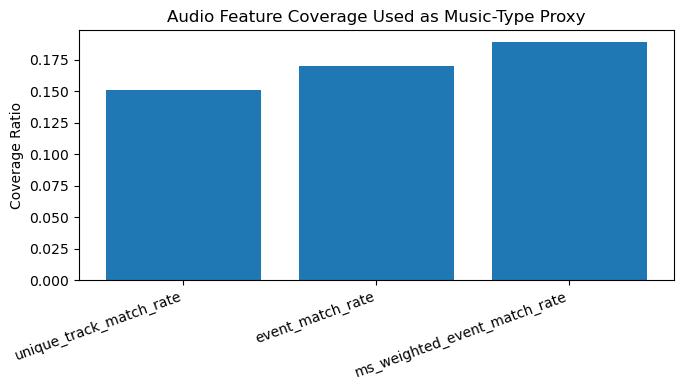

In [4]:
ml_df["rolling_7_total_minutes"] = ml_df["total_minutes"].rolling(window=7, min_periods=1).mean()
ml_df["rolling_7_num_streams"] = ml_df["num_streams"].rolling(window=7, min_periods=1).mean()
ml_df["delta_total_minutes"] = ml_df["total_minutes"].diff().fillna(0)
ml_df["delta_num_streams"] = ml_df["num_streams"].diff().fillna(0)
ml_df["audio_feature_coverage_ratio"] = (
    ml_df["audio_feature_event_count"].fillna(0) / ml_df["num_streams"].replace(0, np.nan)
).fillna(0)
ml_df["has_audio_features"] = (ml_df["audio_feature_event_count"].fillna(0) > 0).astype(int)
ml_df["engagement_ratio"] = (1 - ml_df["skip_rate"]).clip(lower=0, upper=1)
ml_df["artist_track_ratio"] = (
    ml_df["unique_artists"] / ml_df["unique_tracks"].replace(0, np.nan)
).fillna(0)
ml_df["minutes_per_stream"] = (
    ml_df["total_minutes"] / ml_df["num_streams"].replace(0, np.nan)
).fillna(0)

context_features = [
    "is_exam",
    "is_deadline",
    "is_academic_event",
    "is_personal",
    "is_stress_period",
    "is_travel_vacation",
    "is_school_break",
    "is_public_holiday_block",
    "is_long_break",
    "is_lgs_prep",
    "is_yks_prep",
    "is_entrance_exam_high_stress",
]

behavioral_features = [
    "num_streams",
    "unique_artists",
    "unique_tracks",
    "skip_rate",
    "shuffle_rate",
    "session_count",
    "avg_stream_length",
    "median_stream_length",
    "avg_hour",
    "std_hour",
    "night_share",
    "morning_share",
    "afternoon_share",
    "evening_share",
    "engagement_ratio",
    "artist_track_ratio",
    "minutes_per_stream",
    "reason_end_trackdone",
    "reason_end_endplay",
    "reason_start_clickrow",
    "reason_start_trackdone",
    "rolling_7_total_minutes",
    "rolling_7_num_streams",
    "delta_total_minutes",
    "delta_num_streams",
    "weekday_num",
    "month",
    "year",
    "weekend_flag",
]

audio_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "loudness",
    "key",
    "mode",
    "audio_feature_event_count",
    "audio_feature_total_ms",
    "audio_feature_coverage_ratio",
    "has_audio_features",
]

feature_columns = context_features + behavioral_features + audio_features
target_column = "total_minutes"

feature_summary_df = pd.DataFrame(
    {
        "group": ["context", "behavioral", "audio", "total"],
        "feature_count": [
            len(context_features),
            len(behavioral_features),
            len(audio_features),
            len(feature_columns),
        ],
    }
)
display(feature_summary_df)
display(audio_summary_df)

coverage_metrics = audio_summary_df.loc[
    audio_summary_df["metric"].isin(
        ["unique_track_match_rate", "event_match_rate", "ms_weighted_event_match_rate"]
    )
].copy()
coverage_metrics["value"] = pd.to_numeric(coverage_metrics["value"], errors="coerce")

plt.figure(figsize=(7, 4))
plt.bar(coverage_metrics["metric"], coverage_metrics["value"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Coverage Ratio")
plt.title("Audio Feature Coverage Used as Music-Type Proxy")
plt.tight_layout()
plt.show()

## - Chronological Train-Test Design

The main target in this notebook is `total_minutes`, which represents daily listening time.

A chronological split is used instead of a random split so that the model is trained on earlier days and evaluated on later days. This makes the exercise closer to a real forecasting-style generalization problem and avoids overly optimistic leakage from future behavior into the training process.

Target: total_minutes
Train rows: 2148
Test rows: 538
Train range: 2018-09-21 00:00:00 to 2024-09-18 00:00:00
Test range: 2024-09-19 00:00:00 to 2026-03-30 00:00:00


,split,rows,mean_total_minutes,median_total_minutes
0,train,2148,86.399513,76.051950
1,test,538,89.200768,86.384233


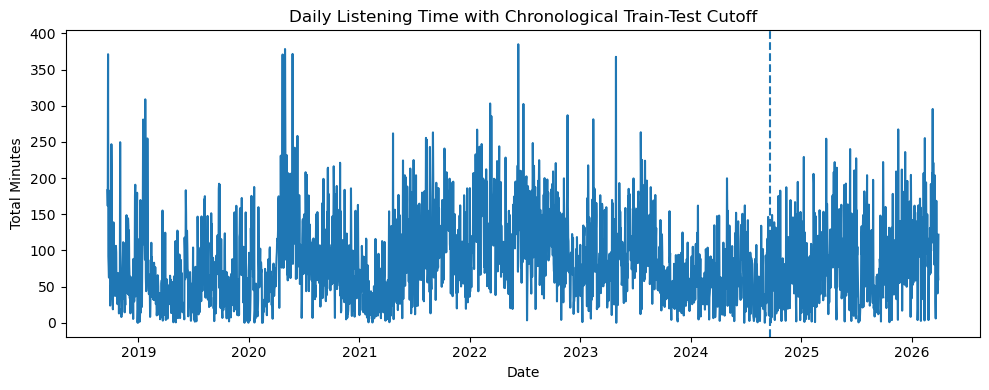

In [5]:
modeling_df = ml_df.dropna(subset=[target_column]).copy().sort_values("date").reset_index(drop=True)

split_index = int(len(modeling_df) * 0.80)
train_df = modeling_df.iloc[:split_index].copy()
test_df = modeling_df.iloc[split_index:].copy()

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()
y_train = train_df[target_column].copy()
y_test = test_df[target_column].copy()

print("Target:", target_column)
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test range:", test_df["date"].min(), "to", test_df["date"].max())

split_summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "mean_total_minutes": [y_train.mean(), y_test.mean()],
        "median_total_minutes": [y_train.median(), y_test.median()],
    }
)
display(split_summary_df)

plt.figure(figsize=(10, 4))
plt.plot(modeling_df["date"], modeling_df["total_minutes"])
plt.axvline(train_df["date"].max(), linestyle="--")
plt.ylabel("Total Minutes")
plt.xlabel("Date")
plt.title("Daily Listening Time with Chronological Train-Test Cutoff")
plt.tight_layout()
plt.show()

## - Reusable Preprocessing Workflow

All predictors used in the regression task are numerical.  
The preprocessing pipeline therefore focuses on:

- median imputation for missing values
- standard scaling

This is especially important because the notebook combines behavioral features, temporal variables, and audio-based variables with different numeric ranges.

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_columns),
    ],
    remainder="drop",
)

print("Number of predictor columns:", len(feature_columns))
print("First 15 predictors:", feature_columns[:15])

Number of predictor columns: 56
First 15 predictors: ['is_exam', 'is_deadline', 'is_academic_event', 'is_personal', 'is_stress_period', 'is_travel_vacation', 'is_school_break', 'is_public_holiday_block', 'is_long_break', 'is_lgs_prep', 'is_yks_prep', 'is_entrance_exam_high_stress', 'num_streams', 'unique_artists', 'unique_tracks']


## - Regression Model Comparison

Since the main question is about how daily listening intensity changes, the central ML task in this notebook is a **regression task**.

The models compared are:

- Dummy Regressor
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor

These models vary from simple linear baselines to more flexible non-linear ensembles.

In [7]:
reg_models = {
    "Baseline Dummy": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=250,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

model_results = []
fitted_models = {}

for model_name, estimator in reg_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", estimator),
        ]
    )
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    model_results.append(
        {
            "Model": model_name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": rmse(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
        }
    )

    fitted_models[model_name] = {
        "pipeline": pipe,
        "predictions": y_pred,
    }

model_results = pd.DataFrame(model_results).sort_values("R2", ascending=False)
display(model_results)

,Model,MAE,RMSE,R2
5,Gradient Boosting,5.135186,8.055168,0.978349
4,Extra Trees,5.064931,8.767963,0.974348
3,Random Forest,5.005599,10.058891,0.966238
2,Ridge Regression,14.149558,19.404526,0.874358
1,Linear Regression,14.164039,19.414814,0.874224
0,Baseline Dummy,43.715707,54.815426,-0.002618


## - Reading the Regression Results

The regression comparison focuses on whether daily listening time can be modeled better than a simple mean-based baseline.

The key metrics are:

- **MAE**: average prediction error in minutes
- **RMSE**: error with stronger penalty for large mistakes
- **R²**: proportion of daily listening variation explained by the model

If the tree-based models outperform the linear baselines, this suggests that daily listening change may involve non-linear relationships between context, behavior, and music-character features.

Best regression model: Gradient Boosting


,Model,MAE,RMSE,R2
5,Gradient Boosting,5.135186,8.055168,0.978349
4,Extra Trees,5.064931,8.767963,0.974348
3,Random Forest,5.005599,10.058891,0.966238
2,Ridge Regression,14.149558,19.404526,0.874358
1,Linear Regression,14.164039,19.414814,0.874224
0,Baseline Dummy,43.715707,54.815426,-0.002618


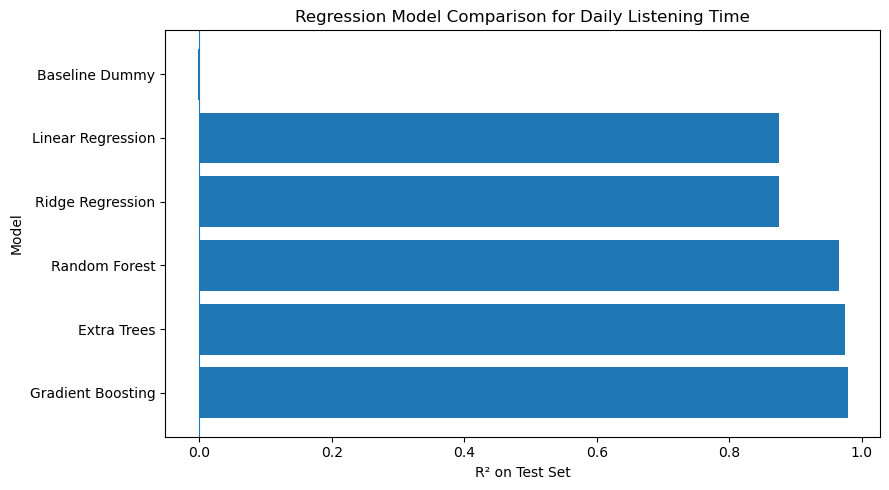

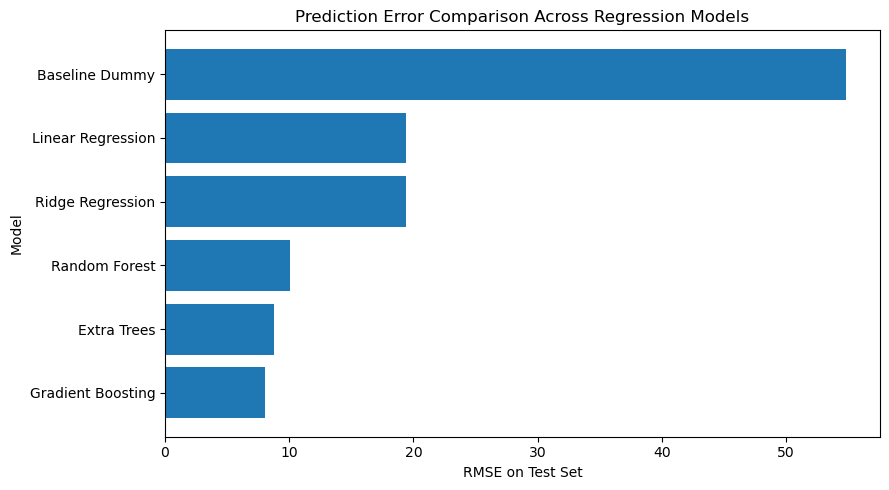

In [8]:
best_model_name = model_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]["pipeline"]
best_predictions = fitted_models[best_model_name]["predictions"]

print("Best regression model:", best_model_name)
display(model_results)

plt.figure(figsize=(9, 5))
plt.barh(model_results["Model"], model_results["R2"])
plt.xlabel("R² on Test Set")
plt.ylabel("Model")
plt.title("Regression Model Comparison for Daily Listening Time")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.barh(model_results["Model"], model_results["RMSE"])
plt.xlabel("RMSE on Test Set")
plt.ylabel("Model")
plt.title("Prediction Error Comparison Across Regression Models")
plt.tight_layout()
plt.show()

## - Time-Series Cross-Validation for the Main Random Forest Regressor

Random Forest is used as the main non-linear model for deeper evaluation because it can capture complex interactions without requiring strong parametric assumptions.

Cross-validation is run only on the training period using a time-series split. This gives a more stable view of how the model behaves across multiple temporal folds.

,metric,train_mean,validation_mean
0,mae,2.417647,7.315284
1,rmse,5.638647,14.028454
2,r2,0.988903,0.931852


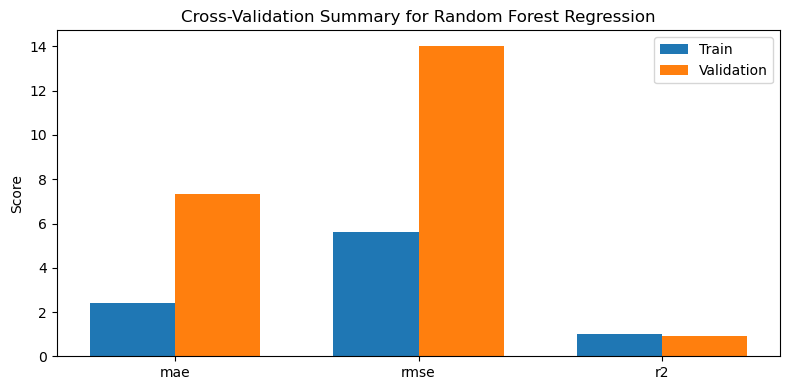

In [9]:
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

tscv = TimeSeriesSplit(n_splits=3)
cv_results = cross_validate(
    rf_pipe,
    X_train,
    y_train,
    cv=tscv,
    scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
    return_train_score=True,
    n_jobs=-1,
)

cv_summary = pd.DataFrame(
    {
        "metric": ["mae", "rmse", "r2"],
        "train_mean": [
            -cv_results["train_neg_mean_absolute_error"].mean(),
            -cv_results["train_neg_root_mean_squared_error"].mean(),
            cv_results["train_r2"].mean(),
        ],
        "validation_mean": [
            -cv_results["test_neg_mean_absolute_error"].mean(),
            -cv_results["test_neg_root_mean_squared_error"].mean(),
            cv_results["test_r2"].mean(),
        ],
    }
)

display(cv_summary)

plt.figure(figsize=(8, 4))
x_positions = np.arange(len(cv_summary))
width = 0.35
plt.bar(x_positions - width / 2, cv_summary["train_mean"], width=width, label="Train")
plt.bar(x_positions + width / 2, cv_summary["validation_mean"], width=width, label="Validation")
plt.xticks(x_positions, cv_summary["metric"])
plt.ylabel("Score")
plt.title("Cross-Validation Summary for Random Forest Regression")
plt.legend()
plt.tight_layout()
plt.show()

## - Random Forest Tuning with Grid Search

To make the main non-linear model more robust, a lightweight grid search is applied to the Random Forest regressor.

The tuned parameters are:

- `n_estimators`
- `max_depth`
- `min_samples_leaf`

The optimization target is negative RMSE, so lower prediction error is preferred.

In [10]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 10, None],
    "model__min_samples_leaf": [2, 3, 5],
}

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print("Best cross-validated RMSE:", round(-grid_search.best_score_, 4))

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best cross-validated RMSE: 13.6045


## - Final Evaluation of the Tuned Regressor

The tuned Random Forest is now evaluated on the held-out test period.

This is the key predictive check for the main research question:  
how well can a model explain day-to-day variation in listening time when it is given context, behavior, and music-character information?

In [11]:
final_predictions = best_rf.predict(X_test)

final_metrics_df = pd.DataFrame(
    [
        {"metric": "MAE", "value": mean_absolute_error(y_test, final_predictions)},
        {"metric": "RMSE", "value": rmse(y_test, final_predictions)},
        {"metric": "R2", "value": r2_score(y_test, final_predictions)},
    ]
)

print("Final Tuned Random Forest Results")
print("---------------------------------")
display(final_metrics_df)

Final Tuned Random Forest Results
---------------------------------


,metric,value
0,MAE,5.078895
1,RMSE,10.126689
2,R2,0.965781


## - Actual vs Predicted Daily Listening Time

This plot checks whether the tuned model follows the broad structure of daily listening time.

If the points cluster around the diagonal, the model is capturing the main trend.  
Larger deviations indicate days whose behavior is harder to explain with the available features.

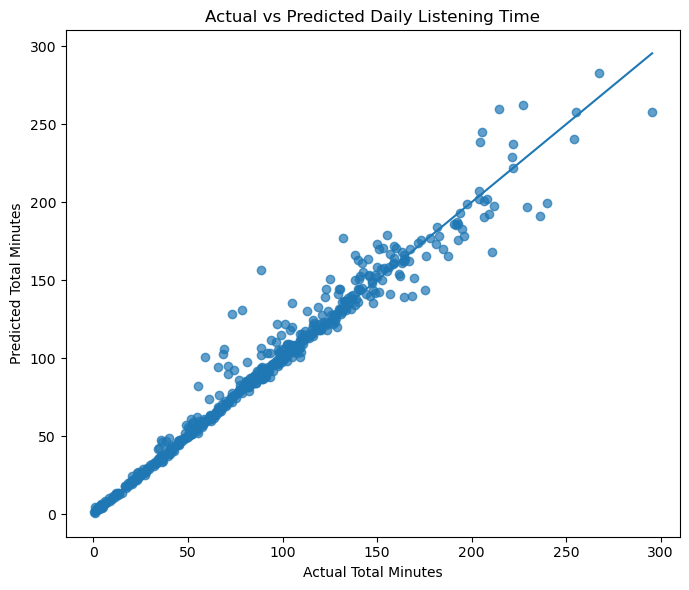

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_predictions, alpha=0.7)

min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Total Minutes")
plt.ylabel("Predicted Total Minutes")
plt.title("Actual vs Predicted Daily Listening Time")
plt.tight_layout()
plt.show()

## - Residual Analysis

Residuals are defined as:

**Residual = Actual Daily Listening Time − Predicted Daily Listening Time**

Residual analysis helps identify whether the model systematically underestimates or overestimates certain types of days.

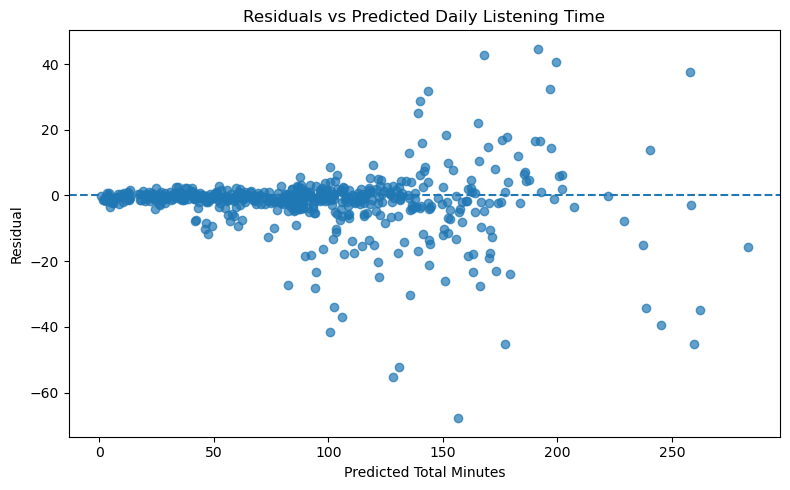

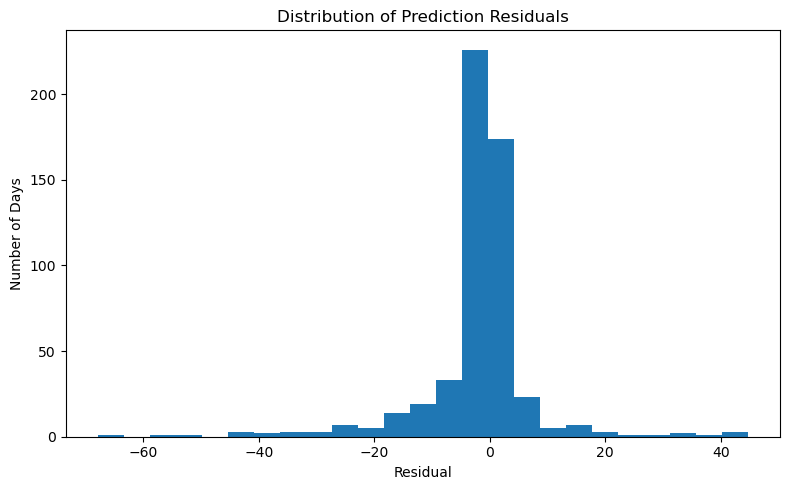

In [13]:
residuals = y_test - final_predictions

plt.figure(figsize=(8, 5))
plt.scatter(final_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Total Minutes")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Daily Listening Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Number of Days")
plt.title("Distribution of Prediction Residuals")
plt.tight_layout()
plt.show()

## - Largest Prediction Errors

The largest errors are especially useful because they show which specific days do not fit the model well.

These may correspond to:

- exceptional special days
- unusual listening marathons
- low-coverage audio days
- calendar-relevant days whose full context is not fully represented in the features

,date,total_minutes,predicted_total_minutes,absolute_error,num_streams,unique_artists,skip_rate,shuffle_rate,is_exam,is_deadline,is_stress_period,is_travel_vacation,is_entrance_exam_high_stress
2562,2025-11-25,88.671533,156.489264,67.817731,199,70,0.653266,0.000000,0,0,1,0,0
2569,2025-12-02,73.238067,128.376157,55.138090,215,109,0.958140,0.000000,0,1,1,0,0
2681,2026-03-26,78.440967,130.712696,52.271729,290,141,0.962069,0.000000,0,0,1,0,0
2364,2025-04-28,214.300383,259.498403,45.198020,137,102,0.613139,0.379562,0,0,1,0,0
2568,2025-12-01,131.937800,177.101631,45.163831,237,114,0.877637,0.000000,0,1,1,0,0
2576,2025-12-10,235.964733,191.316654,44.648079,246,113,0.747967,0.000000,0,0,1,0,0
2417,2025-06-25,210.546983,167.773502,42.773481,262,135,0.812977,0.076336,0,0,0,0,0
2449,2025-08-02,59.212300,100.808340,41.596040,155,71,0.922581,0.000000,0,0,0,0,0
2403,2025-06-11,240.069183,199.544003,40.525180,280,139,0.800000,0.089286,0,0,0,0,0
2288,2025-02-10,205.782000,245.150755,39.368755,147,78,0.639456,0.000000,0,0,0,0,0


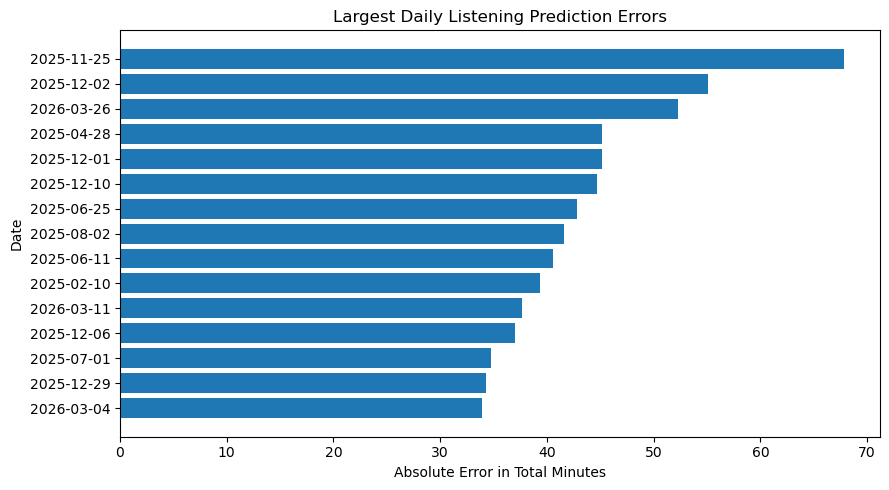

In [14]:
error_df = test_df.copy()
error_df["predicted_total_minutes"] = final_predictions
error_df["residual"] = residuals.values
error_df["absolute_error"] = np.abs(residuals.values)

largest_errors = error_df.sort_values("absolute_error", ascending=False).head(15)
display(
    largest_errors[
        [
            "date",
            "total_minutes",
            "predicted_total_minutes",
            "absolute_error",
            "num_streams",
            "unique_artists",
            "skip_rate",
            "shuffle_rate",
            "is_exam",
            "is_deadline",
            "is_stress_period",
            "is_travel_vacation",
            "is_entrance_exam_high_stress",
        ]
    ]
)

plt.figure(figsize=(9, 5))
top_errors_plot = largest_errors.sort_values("absolute_error", ascending=True)
plt.barh(top_errors_plot["date"].astype(str), top_errors_plot["absolute_error"])
plt.xlabel("Absolute Error in Total Minutes")
plt.ylabel("Date")
plt.title("Largest Daily Listening Prediction Errors")
plt.tight_layout()
plt.show()

## - Feature Influence on Daily Listening Change

This section is one of the most important for the main research question.

The goal is not only to predict total listening time, but also to understand which variables are most informative:

- special-day context indicators
- frequency and diversity signals
- engagement behavior
- audio-feature proxies for music type

,feature,importance_mean,importance_std
12,num_streams,66.988432,1.862048
18,avg_stream_length,11.587287,0.499168
28,minutes_per_stream,10.944889,0.447743
35,delta_total_minutes,6.274121,0.991407
29,reason_end_trackdone,2.394496,0.312121
33,rolling_7_total_minutes,1.367528,0.211628
32,reason_start_trackdone,0.458535,0.059722
19,median_stream_length,0.358625,0.045154
21,std_hour,0.034810,0.013596
53,audio_feature_total_ms,0.030130,0.012925


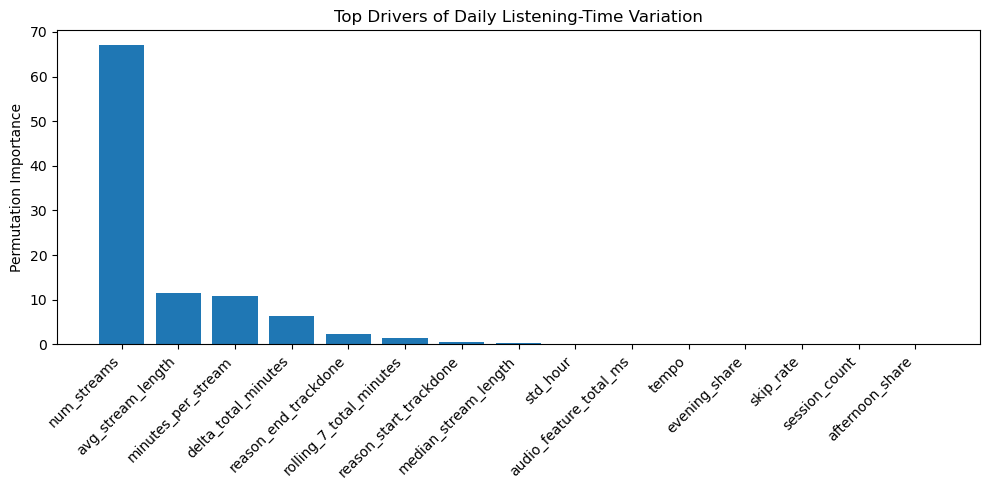

In [15]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

top_importance = importance_df.head(15)
plt.figure(figsize=(10, 5))
plt.bar(top_importance["feature"], top_importance["importance_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Top Drivers of Daily Listening-Time Variation")
plt.tight_layout()
plt.show()

## - Learning Behavior as More Data Becomes Available

A learning curve helps determine whether the model has already absorbed most of the signal or whether more daily observations could still improve the prediction of listening-time variation.

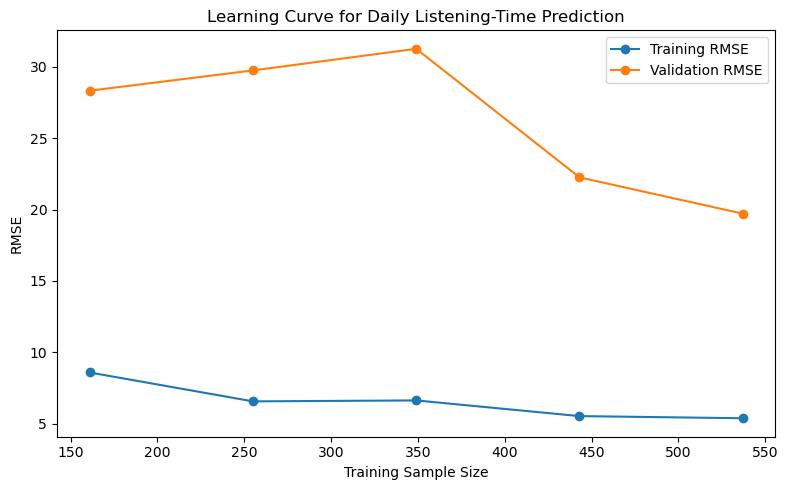

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.3, 1.0, 5),
    n_jobs=-1,
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Training Sample Size")
plt.ylabel("RMSE")
plt.title("Learning Curve for Daily Listening-Time Prediction")
plt.legend()
plt.tight_layout()
plt.show()

## - Optional Classification Task: Daily Listening Intensity Tiers

To complement the regression task, a simple classification task is added by converting daily listening time into three tiers:

- Low listening
- Medium listening
- High listening

This does not replace the regression task.  
Instead, it provides another perspective on whether day-level behavior and audio features can separate different kinds of listening days.

Tier classification accuracy: 0.8476
Tier classification macro F1: 0.8489
              precision    recall  f1-score   support

        High       0.82      0.94      0.87       195
         Low       0.98      0.84      0.90       162
      Medium       0.78      0.76      0.77       181

    accuracy                           0.85       538
   macro avg       0.86      0.84      0.85       538
weighted avg       0.85      0.85      0.85       538



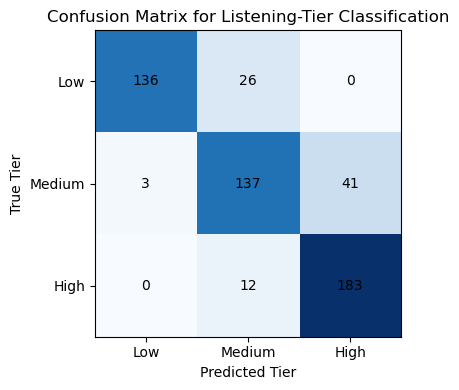

In [17]:
tier_df = modeling_df.copy()
tier_df["listening_tier"] = pd.qcut(
    tier_df["total_minutes"],
    q=3,
    labels=["Low", "Medium", "High"],
)

train_tier = tier_df.iloc[:split_index].copy()
test_tier = tier_df.iloc[split_index:].copy()

X_train_tier = train_tier[feature_columns].copy()
X_test_tier = test_tier[feature_columns].copy()
y_train_tier = train_tier["listening_tier"].copy()
y_test_tier = test_tier["listening_tier"].copy()

tier_classifier = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

tier_classifier.fit(X_train_tier, y_train_tier)
tier_predictions = tier_classifier.predict(X_test_tier)

print("Tier classification accuracy:", round(accuracy_score(y_test_tier, tier_predictions), 4))
print("Tier classification macro F1:", round(f1_score(y_test_tier, tier_predictions, average="macro"), 4))
print(classification_report(y_test_tier, tier_predictions, zero_division=0))

tier_cm = confusion_matrix(y_test_tier, tier_predictions, labels=["Low", "Medium", "High"])
plt.figure(figsize=(5, 4))
plt.imshow(tier_cm, cmap="Blues")
plt.title("Confusion Matrix for Listening-Tier Classification")
plt.xticks([0, 1, 2], ["Low", "Medium", "High"])
plt.yticks([0, 1, 2], ["Low", "Medium", "High"])
for i in range(tier_cm.shape[0]):
    for j in range(tier_cm.shape[1]):
        plt.text(j, i, int(tier_cm[i, j]), ha="center", va="center")
plt.xlabel("Predicted Tier")
plt.ylabel("True Tier")
plt.tight_layout()
plt.show()

## - Overall ML Takeaways

This notebook is built to match the core research question more directly:

**How does daily Spotify listening behavior change across days, both in terms of listening intensity and in terms of the kind of music being played?**

Instead of centering the ML stage only on special-day classification, this notebook treats **daily listening change** as the main object of analysis. In practical terms, the model is asked to explain variation in:

- daily listening duration (`total_minutes`)
- listening frequency (`num_streams`)
- diversity (`unique_artists`, `unique_tracks`)
- engagement signals such as `skip_rate` and `shuffle_rate`
- day structure through hour- and daypart-based features
- music-character proxies through daily audio-feature summaries

**How the audio features were obtained**

The project started from the listening-history data already available locally in the Spotify export. The original cleaned streaming table did not directly contain audio-feature columns such as `danceability`, `energy`, or `valence`. To address that gap without relying on a direct Spotify API-based ML pipeline, the workflow followed a lightweight enrichment strategy:

- event-level Spotify history was reorganized around the track identifiers already present in the export
- a unique track catalog was created from the local listening data
- track-level audio features were matched from external public music-feature tables
- matched features were merged back to event-level listening rows
- event-level audio features were aggregated to the daily level so that they could be used together with daily listening behavior

In numeric terms:

- the local event-level listening table used for enrichment contained **185,469** streaming rows
- the unique track catalog contained **28,660** tracks
- audio features were matched for **4,316** unique tracks
- this corresponds to a unique-track coverage rate of about **15.1%**
- the event-level match rate was about **17.0%**
- the ms-weighted event match rate was about **18.9%**

This means the audio-feature layer is real and usable, but still partial. It should therefore be interpreted as an informative enhancement rather than a complete description of every listened track.

**Why these ML methods were used**

Because the main target in this notebook is continuous daily listening time, the central ML task is a **regression task** rather than a pure classification task. Several models were compared so that the final conclusion would not depend on a single modeling assumption:

- `Dummy Regressor` was used as a baseline
- `Linear Regression` and `Ridge Regression` were used to test whether the daily pattern is mostly linear
- `Random Forest`, `Extra Trees`, and `Gradient Boosting` were used to capture non-linear relationships between context, behavior, and music-character features

This choice is directly connected to the project question. If daily listening behavior really changes in structured ways across contexts, then a model should be able to explain at least part of that day-level variation from the available predictors.

**What the models found**

The regression results were strong. On the held-out test period:

- `Gradient Boosting` was the best model with **MAE ≈ 5.14**, **RMSE ≈ 8.06**, and **R² ≈ 0.978**
- `Extra Trees` also performed strongly with **R² ≈ 0.974**
- `Random Forest` remained strong with **R² ≈ 0.966**
- the linear models were clearly weaker with **R² ≈ 0.874**
- the dummy baseline had effectively no explanatory power

These results suggest that daily listening time is not random; it follows a structure that can be modeled quite successfully from daily behavior, contextual labels, and partial audio-character information.

The optional listening-tier classification task also supported this result. When daily listening time was grouped into low, medium, and high tiers, the classifier reached:

- **accuracy ≈ 0.848**
- **macro F1 ≈ 0.849**

This indicates that the model can also separate broad types of listening days, not only predict the exact number of minutes.

**How to interpret the strongest predictors**

The most influential variables were mainly behavioral:

- `num_streams`
- `avg_stream_length`
- `minutes_per_stream`
- `delta_total_minutes`
- `rolling_7_total_minutes`

Some audio-related variables also appeared in the importance ranking, including:

- `audio_feature_total_ms`
- `tempo`
- `liveness`

This suggests that the main signal in day-to-day variation comes first from **listening structure and intensity**, while the “kind of music” component contributes more as a secondary layer. In other words, the notebook supports the idea that both behavior and music character matter, but behavior is currently the stronger explanatory side.

**If a result is weaker, why might that be?**

The audio-feature side is the clearest example. Audio variables were meaningful enough to include, but they were not the main drivers of prediction. There are several reasons for that:

- the audio-feature coverage is limited
- a complete genre table is not available
- the music-character information is represented through proxies such as energy, valence, tempo, and acousticness rather than a full genre system
- some daily listening outcomes are already strongly explained by direct behavioral variables such as number of streams and average stream length

So a weaker audio contribution does not necessarily mean that music type is irrelevant. It may also reflect incomplete coverage and the fact that the current audio layer is only a partial view of the full listening history.

**How this notebook answers the main research question**

This notebook is relevant to the main project question because it moves beyond asking whether certain special days can be detected. Instead, it models the actual **day-to-day change** in Spotify behavior. The results show that:

- daily listening intensity changes in systematic ways
- those changes are predictable from daily listening structure
- contextual labels such as stress, deadlines, vacations, and entrance-exam periods help define part of that structure
- music-character features add a meaningful, though still limited, layer to the explanation

In short, the ML stage supports the broader finding that Spotify listening is not constant across days. It varies in ways that are connected both to behavioral routines and to contextual conditions.

**Limitations**

Several limitations should remain visible in the final report:

- this is a **single-user dataset**, so the findings are personalized rather than broadly generalizable
- the coverage of special-day labels is limited to the periods for which calendar-based labels were available
- the travel/break labels also cover only certain windows rather than the entire listening history
- the audio-feature layer covers only part of the track catalog:
  about **15.1%** of unique tracks, **17.0%** of event rows, and **18.9%** of ms-weighted listening rows
- some “music type” conclusions rely on audio-feature proxies rather than a complete genre annotation framework

Still, these limitations are also areas for improvement. In the final report version, this notebook could be strengthened by:

- extending special-day labeling coverage where possible
- improving audio-feature coverage with a broader permissible enrichment source
- adding a stronger genre-level representation if a legally and methodologically appropriate source becomes available
- testing versions of the model that rely less directly on features that are mathematically very close to the target

Overall, this notebook provides a useful ML answer to the project question: daily Spotify listening behavior can be modeled successfully, and the strongest evidence points to meaningful change in listening intensity and structure across days, with a smaller but still relevant contribution from music-character features.